In [1]:
# Base imports and path setting
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import jax
import jax.numpy as jnp
import diffrax as dfx
from time import time

import sys
import os
from os.path import dirname
cwd = os.getcwd()
sys.path.append(dirname(cwd))


In [2]:
# Relative import and configs
from src.flows import duffing, trajectory_plot, stream_plot
from src.lyapunov import flow_lyapunov_spectrum, make_batch_lyapunov_solver, kaplan_yorke_dim, boxcount_dimension, poincare_sos

jax.config.update("jax_enable_x64", True)
np.random.seed(42069)

In [3]:
# Flow selection
rhs = duffing
pars = {
    "c": 1,
    "d": -1,
    "a": 0.2,
    "b": 0.3,
    "w": 1,
}
# Initial condition, integration options
z0 = jnp.array([1, 1])
dt = 0.001
N_iters = 2e5
timesteps = np.linspace(0, dt*N_iters, 500000)

steps = 1
burns = 0.2

solver = dfx.Dopri5()
stepsc = dfx.ConstantStepSize()
term = dfx.ODETerm(rhs)
saveat = dfx.SaveAt(ts=timesteps)



MovieWriter imagemagick unavailable; using Pillow instead.


0.0
0.0
0.06346651825433926
0.12693303650867852
0.1903995547630178
0.25386607301735703
0.3173325912716963
0.3807991095260356
0.4442656277803748
0.5077321460347141
0.5711986642890533
0.6346651825433925
0.6981317007977318
0.7615982190520711
0.8250647373064104
0.8885312555607496
0.9519977738150889
1.0154642920694281
1.0789308103237674
1.1423973285781066
1.2058638468324459
1.269330365086785
1.3327968833411243
1.3962634015954636
1.4597299198498028
1.5231964381041423
1.5866629563584815
1.6501294746128208
1.71359599286716
1.7770625111214993
1.8405290293758385
1.9039955476301778
1.967462065884517
2.0309285841388562
2.0943951023931957
2.1578616206475347
2.221328138901874
2.284794657156213
2.3482611754105527
2.4117276936648917
2.475194211919231
2.53866073017357
2.6021272484279097
2.6655937666822487
2.729060284936588
2.792526803190927
2.8559933214452666
2.9194598396996057
2.982926357953945
3.0463928762082846
3.1098593944626236
3.173325912716963
3.236792430971302
3.3002589492256416
3.3637254674799

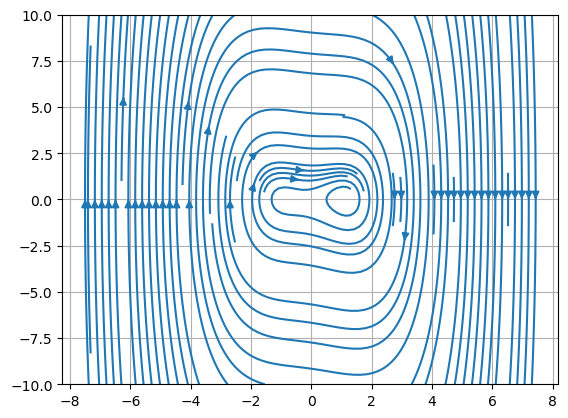

In [ ]:
# Animation of the flow

X_space = np.linspace(-10, 10, 400)
Y_space = np.linspace(-10, 10, 400)
starting_lines = np.array([np.concat((np.linspace(-7.5, -1, 200), np.linspace(-1, 1, 200), np.linspace(1, 7.5, 200)), ),
                           np.full(600, 1)
                           ]).T
X, Y = np.meshgrid(X_space, Y_space)
U, V = rhs(t=0, z=(X, Y), params=pars)
dens=3

fig, ax = plt.subplots()
stream = ax.streamplot(X, Y, U, V, density=dens, start_points=starting_lines)

def animate(ti):
    ax.clear()
    ax.grid(True)
    U, V = rhs(t=ti, z=(X, Y), params=pars)
    stream = ax.streamplot(X, Y, U, V, density=dens, start_points=starting_lines)
    print(ti)
    return stream

anim = animation.FuncAnimation(fig, animate, frames=np.linspace(0, 2*np.pi, 100), interval=50, blit=False, repeat=False)
anim.save( cwd + '/duffing.gif', writer='imagemagick', fps=30)
# plt.show()


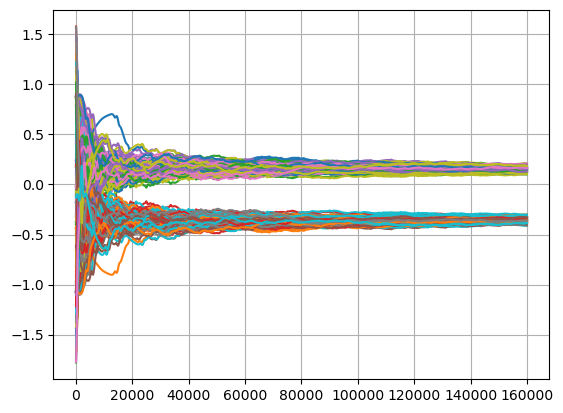

Lyapunov exponent extimate (averaged over random trajectories): [ 0.15642986 -0.35642986] +- [0.02331367 0.02331367]


In [4]:
# First experiment: lyapunov exponents for 100 random initial condition
flurry = jnp.array(np.random.rand(100, 2)*16 - 8)
t0_batch = jnp.zeros(len(flurry))

compute = make_batch_lyapunov_solver(flow=rhs, solver=solver, dt=dt, stepsize=stepsc, n_intervals=N_iters, burn_in=int(N_iters*burns), jacobian=False)
batched_lyap = jax.jit(
    jax.vmap(compute, in_axes=(0, 0, None, None))
)

cum_lyaps = batched_lyap(flurry, t0_batch, pars, steps*dt)
for cum in cum_lyaps:
    plt.plot(cum)
plt.grid(True)
plt.show()
lyap_ext = cum_lyaps.mean(axis=0)[-1, :]
lyap_std = cum_lyaps.std(axis=0)[-1, :]
print(f"Lyapunov exponent extimate (averaged over random trajectories): {lyap_ext} +- {lyap_std}")
